## 0. Setup

All external dependencies used across this notebook (XGBoost for Challenge A,
statsmodels for SARIMA and the Challenge B elasticity regression) are
installed here up front, rather than scattered where first used.


In [1]:
# Setup: install dependencies (run once)
import sys
!{sys.executable} -m pip install -q xgboost statsmodels



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys, os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))

import pandas as pd
import matplotlib.pyplot as plt

from data_cleaning import (
    load_raw, add_flags, fill_missing_metadata,
    fill_discount_bruto, fill_residual_discount_bruto
)

## 1. Data Loading and Cleaning

Dataset: 283,533 transactions, 6 SKUs, 12 warehouses, ~25 months (Jan 2025 - Jan 2027).

Cleaning rules are implemented in `src/data_cleaning.py` and summarized step by step below.

In [3]:
df = load_raw("../data/20260806_prueba_tecnica_dataset.csv")
print(f"Total rows: {len(df)}")

df = add_flags(df)
print(f"Cancelled tickets: {df['is_cancelled'].sum()}")
print(f"Gifts/samples: {df['is_gift'].sum()}")

df = fill_missing_metadata(df)

missing_before = df[["discount", "bruto"]].isnull().sum()
pct_before = (missing_before / len(df) * 100).round(2)
print("\nMissing before imputation:")
print(pd.concat([missing_before.rename("rows"), pct_before.rename("% of total")], axis=1))

df = fill_discount_bruto(df)
df = fill_residual_discount_bruto(df)

print("\nRemaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Total rows: 283533
Cancelled tickets: 500
Gifts/samples: 500

Missing before imputation:
           rows  % of total
discount  15538        5.48
bruto       110        0.04

Remaining nulls:
id_combo        215544
combo           215544
bruto                1
product_cost       110
dtype: int64


**Decision:** both row types are kept (not dropped), marked with a flag.
- `is_cancelled`: excluded from any demand aggregation (Challenge A).
- `is_gift`: counts as physical demand (Challenge A), but excluded from
  effective price / elasticity calculations (Challenge B), since unit_price=0
  is not a real market price.

**Decision:** the row with missing metadata (category, subcategory, brand,
basket) was filled by mapping from other rows with the same `product_code`,
since these fields are constant per SKU. No row was dropped.

**Decision:** `discount`, `bruto`, and `sell_in_amount` are algebraically
related: `bruto = sell_in_amount / (1 - discount)`. Most missing values were
resolved by deriving one column from the other two. Organic sales
(`id_combo` null) with a remaining null default to `discount = 0`.

For 3 rows that belonged to a promotion but had both values missing,
`discount` was imputed with the average discount of that same `id_combo`.
One row remains null in `bruto`: a gift transaction (`amount=0`,
`discount=1.0`) where the formula is mathematically undefined (division by
zero) — left null rather than forcing an arbitrary value.

In [4]:
from data_cleaning import fill_product_cost

df = fill_product_cost(df)
print("Remaining nulls in product_cost:", df["product_cost"].isnull().sum())
print("Imputed rows:", df["product_cost_imputed"].sum())

Remaining nulls in product_cost: 0
Imputed rows: 110


**Decision:** unit cost is NOT constant per SKU over the full period — it's a
step function driven by periodic supplier cost updates. Missing `product_cost`
was imputed using the median unit cost of that SKU **within the same
year-month**, avoiding cross-period contamination.

## 2. Exploratory Analysis: Weekly Demand by SKU

In [5]:
demand = df[~df["is_cancelled"]].copy()
demand["week"] = demand["date"].dt.to_period("W").dt.start_time

weekly_demand = (
    demand.groupby(["product_name", "week"])["sell_in_quantity"]
    .sum()
    .reset_index()
)

weekly_demand.head()

,product_name,week,sell_in_quantity
0,Antitranspirante 150 ml C,2025-01-06,380
1,Antitranspirante 150 ml C,2025-01-13,374
2,Antitranspirante 150 ml C,2025-01-20,434
3,Antitranspirante 150 ml C,2025-01-27,371
4,Antitranspirante 150 ml C,2025-02-03,350


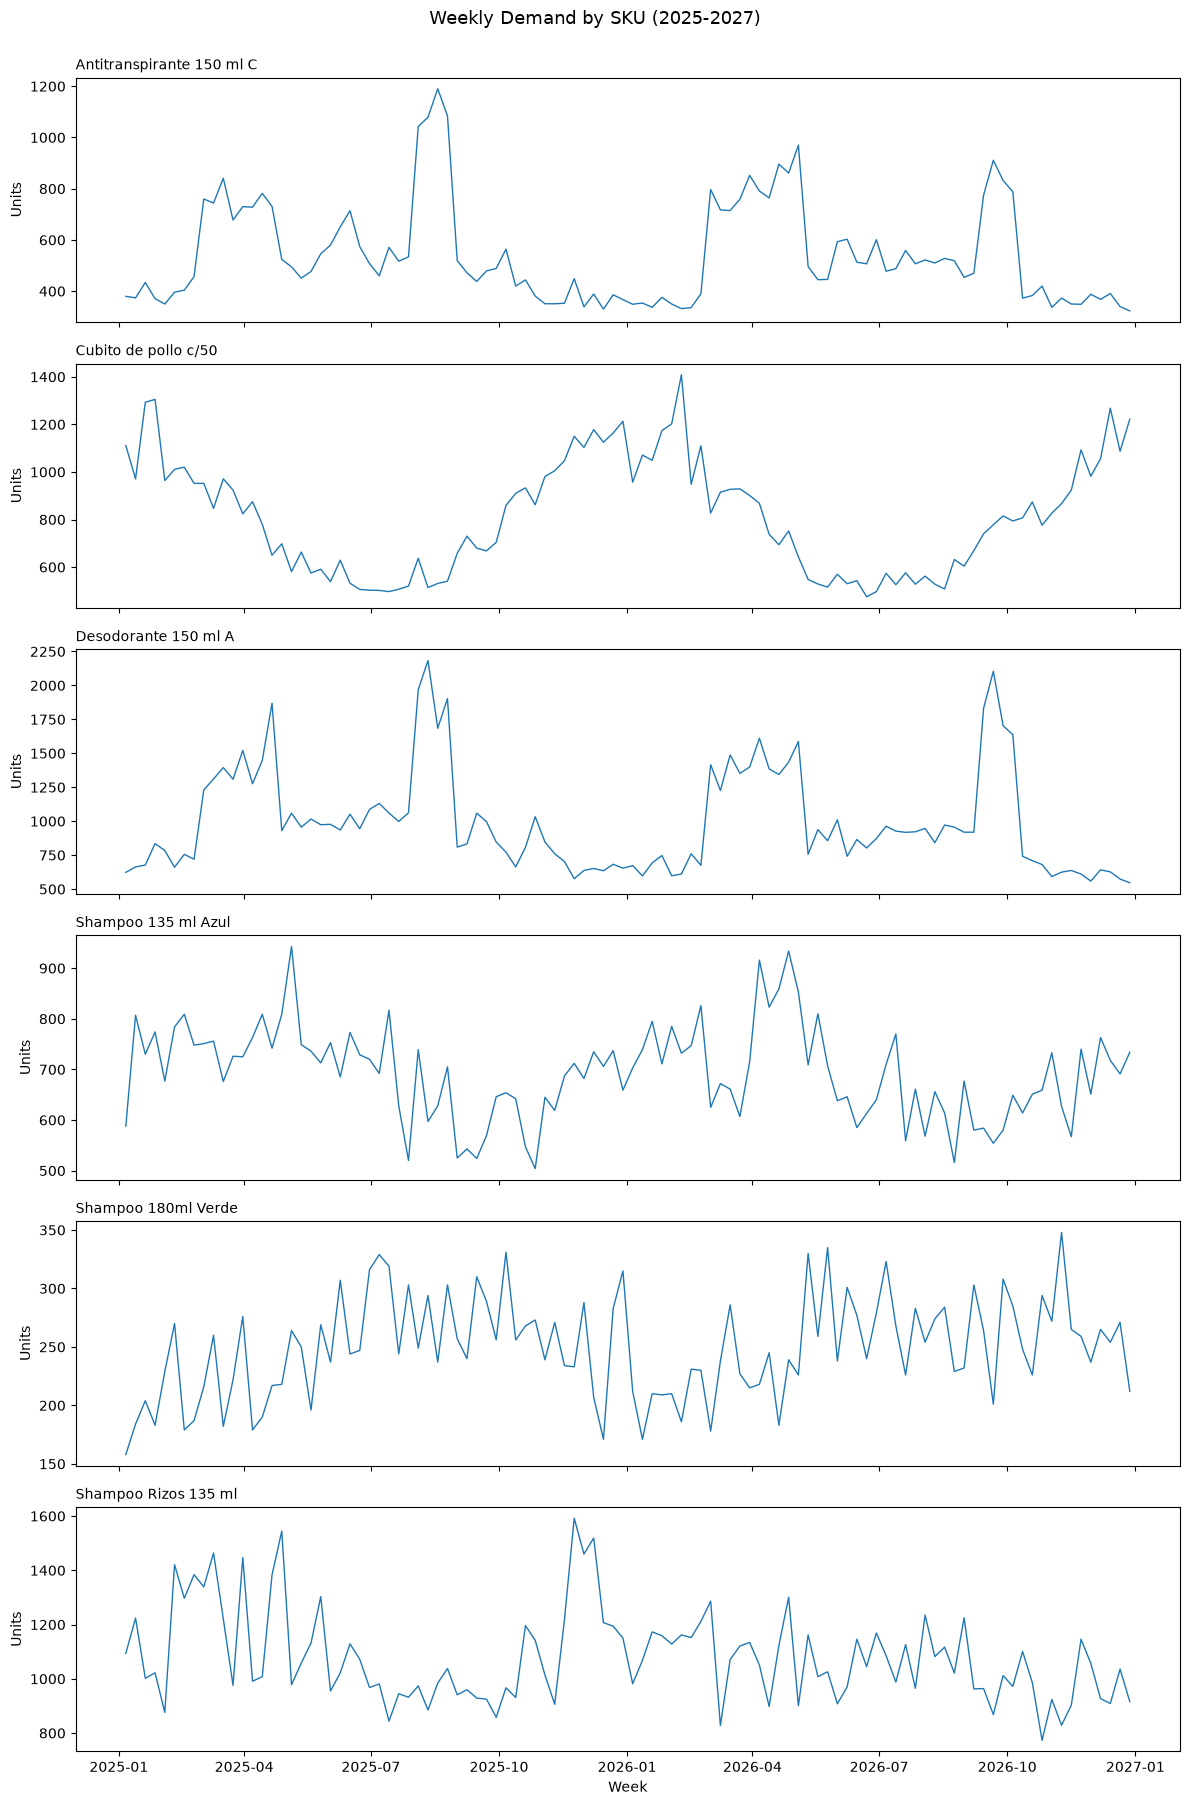

In [6]:
skus = weekly_demand["product_name"].unique()

fig, axes = plt.subplots(len(skus), 1, figsize=(12, 3 * len(skus)), sharex=True)

for ax, sku in zip(axes, skus):
    data = weekly_demand[weekly_demand["product_name"] == sku]
    ax.plot(data["week"], data["sell_in_quantity"], linewidth=1)
    ax.set_title(sku, fontsize=10, loc="left")
    ax.set_ylabel("Units")

axes[-1].set_xlabel("Week")
fig.suptitle("Weekly Demand by SKU (2025-2027)", fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig("../outputs/weekly_demand_by_sku.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Challenge A: Demand Forecasting

Selected SKUs: Desodorante 150 ml A, Cubito de pollo c/50, Shampoo Rizos 135 ml
(chosen for contrasting patterns: strong seasonality, trend+seasonality, and
noisier/harder-to-forecast demand, respectively).

**Validation strategy:** last 10 weeks held out as test set (walk-forward,
no random split — avoids future information leakage). Baseline compared
against more sophisticated models.

In [7]:
selected_skus = ["Desodorante 150 ml A", "Cubito de pollo c/50", "Shampoo Rizos 135 ml"]

forecast_data = weekly_demand[weekly_demand["product_name"].isin(selected_skus)].copy()
forecast_data = forecast_data.sort_values(["product_name", "week"])

TEST_WEEKS = 10

for sku in selected_skus:
    n_weeks = forecast_data[forecast_data["product_name"] == sku].shape[0]
    print(f"{sku}: {n_weeks} weeks total")

Desodorante 150 ml A: 104 weeks total
Cubito de pollo c/50: 104 weeks total
Shampoo Rizos 135 ml: 104 weeks total


### 3.1 Baseline: Seasonal Naive

Predicts demand as equal to the same week, 52 weeks prior — respects the
annual seasonality observed in the EDA. This is the floor any more
sophisticated model must beat.

In [8]:
import numpy as np
def train_test_split_series(df_sku, test_weeks=TEST_WEEKS):
    df_sku = df_sku.sort_values("week").reset_index(drop=True)
    train = df_sku.iloc[:-test_weeks]
    test = df_sku.iloc[-test_weeks:]
    return train, test


def seasonal_naive_forecast(train, test, season_length=52):
    history = train["sell_in_quantity"].values
    preds = []
    for i in range(len(test)):
        idx = len(history) - season_length + i
        preds.append(history[idx] if idx >= 0 else np.nan)
    return np.array(preds)


results = {}
for sku in selected_skus:
    df_sku = forecast_data[forecast_data["product_name"] == sku]
    train, test = train_test_split_series(df_sku)
    preds = seasonal_naive_forecast(train, test)
    results[sku] = {"train": train, "test": test, "seasonal_naive_preds": preds}

for sku in selected_skus:
    print(sku, "-> test actual:", results[sku]["test"]["sell_in_quantity"].values[:3], "...")
    print(sku, "-> naive preds: ", results[sku]["seasonal_naive_preds"][:3], "...")

Desodorante 150 ml A -> test actual: [681 592 625] ...
Desodorante 150 ml A -> naive preds:  [1033  847  760] ...
Cubito de pollo c/50 -> test actual: [776 827 867] ...
Cubito de pollo c/50 -> naive preds:  [ 862  981 1005] ...
Shampoo Rizos 135 ml -> test actual: [773 924 829] ...
Shampoo Rizos 135 ml -> naive preds:  [1142 1014  906] ...


**Observation:** the seasonal naive baseline overpredicts Desodorante's
test-period demand (e.g. 1033 vs actual 681 in the first test week). A likely
explanation: promotional timing shifted between years — the 2026 "Cierre
Trimestre" combo ran Sep-Oct, ending right before this test window, while the
equivalent period 52 weeks prior had different promo timing. Seasonal naive
cannot account for promo activity, since it only copies last year's value
blindly. This motivates trying a model that can incorporate a promo flag as
a feature.

In [9]:
def mape(actual, pred):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

def wmape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual)) * 100

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))


baseline_metrics = []
for sku in selected_skus:
    actual = results[sku]["test"]["sell_in_quantity"].values
    pred = results[sku]["seasonal_naive_preds"]
    baseline_metrics.append({
        "sku": sku,
        "MAPE": mape(actual, pred),
        "WMAPE": wmape(actual, pred),
        "RMSE": rmse(actual, pred),
    })

baseline_df = pd.DataFrame(baseline_metrics)
print(baseline_df)

                    sku       MAPE      WMAPE        RMSE
0  Desodorante 150 ml A  18.762656  18.933552  155.641897
1  Cubito de pollo c/50  10.712028  10.196001  111.587634
2  Shampoo Rizos 135 ml  31.613514  31.656051  336.114266


**Baseline results (Seasonal Naive):**

| SKU | MAPE | WMAPE | RMSE |
|---|---|---|---|
| Desodorante 150 ml A | 18.8% | 18.9% | 155.6 |
| Cubito de pollo c/50 | 10.7% | 10.2% | 111.6 |
| Shampoo Rizos 135 ml | 31.6% | 31.7% | 336.1 |

Error ranks as expected from the EDA: Cubito (clear pattern) < Desodorante
(promo-timing sensitive) < Shampoo Rizos (noisiest). This ordering is the
floor a more sophisticated model must beat, ideally by the largest margin on
Desodorante, where a promo-aware model should have the most to gain.

### 3.2 Model 1: XGBoost

Chosen first because it can incorporate a promo-activity flag as a feature —
directly addressing the gap identified in the baseline (seasonal naive
cannot see promotions). Features: lags (1, 2, 52 weeks), month, week-of-year,
and promo flag/discount depth.

In [10]:
demand["has_promo"] = demand["id_combo"].notnull()

weekly_promo = (
    demand.groupby(["product_name", "week"])
    .agg(
        sell_in_quantity=("sell_in_quantity", "sum"),
        has_promo=("has_promo", "max"),           # 1 si al menos una venta esa semana fue con promo
        avg_discount=("discount", "mean"),
    )
    .reset_index()
)

weekly_promo.head(10)

,product_name,week,sell_in_quantity,has_promo,avg_discount
0,Antitranspirante 150 ml C,2025-01-06,380,False,-0.000161
1,Antitranspirante 150 ml C,2025-01-13,374,False,0.004233
2,Antitranspirante 150 ml C,2025-01-20,434,False,0.000114
3,Antitranspirante 150 ml C,2025-01-27,371,False,0.000231
4,Antitranspirante 150 ml C,2025-02-03,350,False,0.000131
5,Antitranspirante 150 ml C,2025-02-10,396,False,0.003938
6,Antitranspirante 150 ml C,2025-02-17,404,False,0.000167
7,Antitranspirante 150 ml C,2025-02-24,457,False,0.000005
8,Antitranspirante 150 ml C,2025-03-03,760,True,0.153601
9,Antitranspirante 150 ml C,2025-03-10,744,True,0.153677


**Note:** `avg_discount` is not exactly 0 in non-promo weeks (e.g. -0.000161)
— this is floating-point noise inherited from the discount imputation step
in `data_cleaning.py`, not a data quality issue. It's negligible (~1e-4
magnitude) and does not affect the promo flag (`has_promo`), which is based
on `id_combo` presence, not on the discount value itself.

**Validation:** `has_promo` correctly flips to `True` exactly at 2025-03-03,
matching the "Combo Verano Antitranspirante" start date from the combo
summary table, with demand jumping from 457 to 760 units that same week —
confirms the weekly aggregation and promo flag are correctly aligned.

In [11]:
def build_features(df_sku):
    df_sku = df_sku.sort_values("week").reset_index(drop=True)
    df_sku["lag_1"] = df_sku["sell_in_quantity"].shift(1)
    df_sku["lag_2"] = df_sku["sell_in_quantity"].shift(2)
    df_sku["month"] = df_sku["week"].dt.month
    df_sku["week_of_year"] = df_sku["week"].dt.isocalendar().week.astype(int)
    return df_sku

featured = []
for sku in selected_skus:
    df_sku = weekly_promo[weekly_promo["product_name"] == sku].copy()
    df_sku = build_features(df_sku)
    featured.append(df_sku)

featured_data = pd.concat(featured, ignore_index=True)
featured_data = featured_data.dropna(subset=["lag_1", "lag_2"]).reset_index(drop=True)

print(featured_data.shape)
print(featured_data.isnull().sum())

(306, 9)
product_name        0
week                0
sell_in_quantity    0
has_promo           0
avg_discount        0
lag_1               0
lag_2               0
month               0
week_of_year        0
dtype: int64


**Decision:** `lag_52` was dropped as a feature. With only 94 training weeks
per SKU, requiring `lag_52` would cut the training set roughly in half (156
of 312 rows are null, since the entire first year has no "52 weeks prior"
data to reference). `month` and `week_of_year` are kept instead — they
capture the same seasonal signal (time of year) without depending on a
single noisy value from exactly one year back, and without sacrificing half
the already-limited training data.

`lag_1` and `lag_2` nulls (3 and 6 rows respectively, one per SKU at the
start of its series) are negligible and dropped directly.

Trained one XGBoost model per SKU (rather than one pooled model), given the
small dataset size (92 training weeks per SKU) — a per-SKU model is simpler
to interpret and avoids the model having to also learn cross-SKU differences
with so little data.

Hyperparameters (`max_depth=3`, `n_estimators=100`) were kept conservative
on purpose: with only 92 training rows, an overly complex model would
overfit easily.

In [12]:
from xgboost import XGBRegressor

FEATURES = ["lag_1", "lag_2", "month", "week_of_year", "has_promo", "avg_discount"]
TARGET = "sell_in_quantity"

xgb_results = {}

for sku in selected_skus:
    df_sku = featured_data[featured_data["product_name"] == sku].sort_values("week").reset_index(drop=True)

    train = df_sku.iloc[:-TEST_WEEKS]
    test = df_sku.iloc[-TEST_WEEKS:]

    X_train, y_train = train[FEATURES].astype(float), train[TARGET]
    X_test, y_test = test[FEATURES].astype(float), test[TARGET]

    model = XGBRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    xgb_results[sku] = {
        "model": model,
        "X_train": X_train, "y_train": y_train,
        "X_test": X_test, "y_test": y_test,
        "preds": preds,
        "test_weeks": test["week"].values,
    }
    print(sku, "-> preds:", preds[:3].round(1), "actual:", y_test.values[:3])

xgb_metrics = []
for sku in selected_skus:
    actual = xgb_results[sku]["y_test"].values
    pred = xgb_results[sku]["preds"]
    xgb_metrics.append({
        "SKU": sku,
        "MAPE (%)": round(mape(actual, pred), 2),
        "WMAPE (%)": round(wmape(actual, pred), 2),
        "RMSE": round(rmse(actual, pred), 2),
    })

xgb_df = pd.DataFrame(xgb_metrics)
print("=== XGBoost Performance (Test 10 weeks) ===")
print(xgb_df)

Desodorante 150 ml A -> preds: [646.9 645.4 642. ] actual: [681 592 625]
Cubito de pollo c/50 -> preds: [872.1 833.3 921. ] actual: [776 827 867]
Shampoo Rizos 135 ml -> preds: [1196.1  986.6  975.3] actual: [773 924 829]
=== XGBoost Performance (Test 10 weeks) ===
                    SKU  MAPE (%)  WMAPE (%)    RMSE
0  Desodorante 150 ml A     10.26       9.99   77.82
1  Cubito de pollo c/50      6.49       6.68   86.76
2  Shampoo Rizos 135 ml     14.85      13.91  168.58


In [13]:
# --- Recursive (deployment-realistic) XGBoost evaluation on the test holdout ---
# The WMAPE above uses real lag_1/lag_2 at each test week (one-step-ahead rolling
# evaluation). The actual 8-12 week forecast in section 3.5 is recursive: lag_1/lag_2
# for future weeks are the model's own prior predictions, not real values. This block
# re-evaluates XGBoost on the same 10-week holdout, but recursively, to measure how much
# WMAPE degrades under the same conditions the deployed forecast actually faces.

xgb_recursive_metrics = []
xgb_recursive_results = {}

for sku in selected_skus:
    df_sku = featured_data[featured_data["product_name"] == sku].sort_values("week").reset_index(drop=True)
    train = df_sku.iloc[:-TEST_WEEKS]
    test = df_sku.iloc[-TEST_WEEKS:]

    X_train, y_train = train[FEATURES].astype(float), train[TARGET]
    model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
    model.fit(X_train, y_train)

    # same convention as the section 3.5 forecast: promo features held at last known value,
    # since in a true forward deployment you wouldn't know future promo activity either
    history = list(train[TARGET].values)
    last_has_promo = train["has_promo"].iloc[-1]
    last_avg_discount = train["avg_discount"].iloc[-1]

    recursive_preds = []
    for _, row in test.iterrows():
        feat_row = pd.DataFrame([{
            "lag_1": history[-1],
            "lag_2": history[-2],
            "month": row["month"],
            "week_of_year": row["week_of_year"],
            "has_promo": last_has_promo,
            "avg_discount": last_avg_discount,
        }])[FEATURES].astype(float)
        pred = model.predict(feat_row)[0]
        recursive_preds.append(pred)
        history.append(pred)  # feed the model's own prediction forward, not the real value

    actual = test[TARGET].values
    recursive_preds = np.array(recursive_preds)
    xgb_recursive_results[sku] = {"actual": actual, "preds": recursive_preds}

    xgb_recursive_metrics.append({
        "SKU": sku,
        "MAPE (%)": round(mape(actual, recursive_preds), 2),
        "WMAPE (%)": round(wmape(actual, recursive_preds), 2),
        "RMSE": round(rmse(actual, recursive_preds), 2),
    })

xgb_recursive_df = pd.DataFrame(xgb_recursive_metrics)
print("=== XGBoost Performance, RECURSIVE mode (Test 10 weeks) ===")
print(xgb_recursive_df)

=== XGBoost Performance, RECURSIVE mode (Test 10 weeks) ===
                    SKU  MAPE (%)  WMAPE (%)    RMSE
0  Desodorante 150 ml A      8.01       7.71   56.17
1  Cubito de pollo c/50      8.10       7.75   85.36
2  Shampoo Rizos 135 ml     15.25      14.24  154.21


### 3.3 Model 2: SARIMA

A classical statistical model using only the series' own past values (no
external regressors). Included as a second comparison to check whether a
simpler, promo-blind model still performs competitively.

In [14]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

sarima_results = {}

for sku in selected_skus:
    train_series = results[sku]["train"]["sell_in_quantity"].reset_index(drop=True)
    test_series = results[sku]["test"]["sell_in_quantity"].reset_index(drop=True)

    model = SARIMAX(
        train_series,
        order=(1, 1, 1),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    preds = fitted.forecast(steps=TEST_WEEKS)

    sarima_results[sku] = {
        "model": fitted,
        "preds": preds.values,
        "y_test": test_series.values,
    }
    print(sku, "-> preds:", preds.values[:3].round(1), "actual:", test_series.values[:3])

Desodorante 150 ml A -> preds: [809.6 879.9 929.1] actual: [681 592 625]
Cubito de pollo c/50 -> preds: [851.3 859.4 856.5] actual: [776 827 867]
Shampoo Rizos 135 ml -> preds: [1013.  1018.5 1019.6] actual: [773 924 829]


In [15]:
sarima_metrics = []
for sku in selected_skus:
    actual = sarima_results[sku]["y_test"]
    pred = sarima_results[sku]["preds"]
    sarima_metrics.append({
        "SKU": sku,
        "MAPE (%)": round(mape(actual, pred), 2),
        "WMAPE (%)": round(wmape(actual, pred), 2),
        "RMSE": round(rmse(actual, pred), 2),
    })

sarima_df = pd.DataFrame(sarima_metrics)
print("=== SARIMA Performance (Test 10 weeks) ===")
print(sarima_df)

=== SARIMA Performance (Test 10 weeks) ===
                    SKU  MAPE (%)  WMAPE (%)    RMSE
0  Desodorante 150 ml A     59.87      58.78  371.59
1  Cubito de pollo c/50     15.85      17.32  218.28
2  Shampoo Rizos 135 ml     12.68      11.98  128.76


In [16]:
comparison = baseline_df.rename(columns={"sku": "SKU", "MAPE": "Naive MAPE (%)", "WMAPE": "Naive WMAPE (%)", "RMSE": "Naive RMSE"})
comparison = comparison.merge(
    xgb_recursive_df.rename(columns={"MAPE (%)": "XGBoost MAPE (%)", "WMAPE (%)": "XGBoost WMAPE (%)", "RMSE": "XGBoost RMSE"}),
    on="SKU",
)
comparison = comparison.merge(
    sarima_df.rename(columns={"MAPE (%)": "SARIMA MAPE (%)", "WMAPE (%)": "SARIMA WMAPE (%)", "RMSE": "SARIMA RMSE"}),
    on="SKU",
)

comparison
winner = {}
for _, row in comparison.iterrows():
    sku = row["SKU"]
    scores = {
        "Seasonal Naive": row["Naive WMAPE (%)"],
        "XGBoost": row["XGBoost WMAPE (%)"],
        "SARIMA": row["SARIMA WMAPE (%)"],
    }
    best_model = min(scores, key=scores.get)
    winner[sku] = best_model
    print(f"{sku}: best model -> {best_model} (WMAPE {scores[best_model]:.2f}%)")

Desodorante 150 ml A: best model -> XGBoost (WMAPE 7.71%)
Cubito de pollo c/50: best model -> XGBoost (WMAPE 7.75%)
Shampoo Rizos 135 ml: best model -> SARIMA (WMAPE 11.98%)


**Model comparison (Test 10 weeks, WMAPE):**

| SKU | Naive | XGBoost (recursive) | SARIMA | Winner |
|---|---|---|---|---|
| Desodorante 150 ml A | 18.9% | **7.71%** | 58.78% | XGBoost |
| Cubito de pollo c/50 | 10.2% | **7.75%** | 17.32% | XGBoost |
| Shampoo Rizos 135 ml | 31.7% | 14.24% | **11.98%** | SARIMA |

No single model wins across all SKUs — the best choice depends on what drives
each series:

- **Desodorante:** SARIMA is worse than even the naive baseline (58.78%
  WMAPE). Its forecast trends upward (810 → 880 → 929) while actual demand
  falls (681 → 592 → 625) — a pure ARIMA(1,1,1) with no promo awareness
  simply extrapolates the tail of a recent promotion after it has ended.
  This is the clearest evidence in the whole analysis that promo-aware
  features matter: XGBoost, which sees `has_promo`/`avg_discount`,cuts the error to well under half of the baseline.
  
- **Cubito de pollo:** SARIMA also underperforms both XGBoost and the naive
  baseline (17.32% vs 6.68% vs 10.2%). Consistent with the EDA — this SKU's
  signal is seasonality + trend, and SARIMA was deliberately run *without* a
  seasonal component (see 3.3 decision note), so it loses exactly the signal
  that explains this series best. Seasonal naive, despite its simplicity,
  captures that seasonality directly by copying last year's value.
- **Shampoo Rizos:** SARIMA edges out XGBoost (11.98% vs 13.91%). This is the
  noisiest SKU with the weakest seasonal/promo signal — with only 92 training
  rows, XGBoost has less structure to learn from and is more prone to
  overfitting the lag features to noise, while a simple autoregressive model
  captures the short-term persistence well enough.

**Selected model per SKU:** XGBoost for Desodorante and Cubito de pollo,
SARIMA for Shampoo Rizos. This per-SKU selection (rather than a single
model for all three) is itself a finding: model choice should follow how
promo-driven, seasonal, or noisy a given SKU's demand is.

### 3.5 Final Forecast: 8–12 Weeks Ahead

The winning model per SKU (selected by lowest WMAPE in section 3.4) is
re-trained using the **full** available history (train + test combined), and
used to generate a forecast beyond the observed data.

For XGBoost, this requires a **recursive** forecast: since `lag_1`/`lag_2`
depend on actual past demand, and no real values exist for future weeks, each
predicted value is fed back in as the lag input for the next step. This means
forecast errors can compound over the horizon — expected and acceptable for
an 8-12 week window, but a reason not to trust this approach much further out.

**Limitation:** `has_promo` and `avg_discount` are held constant at their last
observed value for all future weeks, since the dataset has no promo calendar
beyond the historical period. If a real promo calendar for the forecast
window becomes available, it should replace this assumption — the current
forecast should be read as a "no new promotions" scenario, not an
unconditional prediction.

In [17]:
FORECAST_WEEKS = 10  # entre 8 y 12, ajustable

future_forecasts = {}

for sku in selected_skus:
    full_series = forecast_data[forecast_data["product_name"] == sku].sort_values("week").reset_index(drop=True)
    last_week = full_series["week"].max()
    future_weeks = pd.date_range(last_week + pd.Timedelta(weeks=1), periods=FORECAST_WEEKS, freq="W-MON")

    if winner[sku] == "SARIMA":
        full_y = full_series["sell_in_quantity"].reset_index(drop=True)
        model = SARIMAX(full_y, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0),
                         enforce_stationarity=False, enforce_invertibility=False)
        fitted = model.fit(disp=False)
        preds = fitted.forecast(steps=FORECAST_WEEKS).values

    elif winner[sku] == "XGBoost":
        df_sku_full = featured_data[featured_data["product_name"] == sku].sort_values("week").reset_index(drop=True)
        X_full, y_full = df_sku_full[FEATURES].astype(float), df_sku_full[TARGET]
        model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
        model.fit(X_full, y_full)

        history = list(df_sku_full["sell_in_quantity"].values)
        last_has_promo = df_sku_full["has_promo"].iloc[-1]
        last_avg_discount = df_sku_full["avg_discount"].iloc[-1]
        preds = []
        for wk in future_weeks:
            row = pd.DataFrame([{
                "lag_1": history[-1],
                "lag_2": history[-2],
                "month": wk.month,
                "week_of_year": wk.isocalendar()[1],
                "has_promo": last_has_promo,
                "avg_discount": last_avg_discount,
            }])[FEATURES].astype(float)
            pred = model.predict(row)[0]
            preds.append(pred)
            history.append(pred)
        preds = np.array(preds)

    else:  # Seasonal Naive
        history = full_series["sell_in_quantity"].values
        preds = np.array([
            history[len(history) - 52 + i] if (len(history) - 52 + i) >= 0 else np.nan
            for i in range(FORECAST_WEEKS)
        ])

    future_forecasts[sku] = pd.DataFrame({"week": future_weeks, "forecast": preds, "model": winner[sku]})
    print(f"{sku} ({winner[sku]}):")
    print(future_forecasts[sku].to_string(index=False))
    print()

Desodorante 150 ml A (XGBoost):
      week   forecast   model
2027-01-04 650.241699 XGBoost
2027-01-11 672.305359 XGBoost
2027-01-18 657.323303 XGBoost
2027-01-25 693.286133 XGBoost
2027-02-01 688.005188 XGBoost
2027-02-08 636.171631 XGBoost
2027-02-15 640.015381 XGBoost
2027-02-22 677.753601 XGBoost
2027-03-01 677.753601 XGBoost
2027-03-08 671.059753 XGBoost

Cubito de pollo c/50 (XGBoost):
      week    forecast   model
2027-01-04 1094.703125 XGBoost
2027-01-11 1132.092896 XGBoost
2027-01-18 1094.703125 XGBoost
2027-01-25 1151.951782 XGBoost
2027-02-01 1090.177368 XGBoost
2027-02-08 1134.526489 XGBoost
2027-02-15 1075.919556 XGBoost
2027-02-22 1134.526489 XGBoost
2027-03-01 1063.114624 XGBoost
2027-03-08 1122.624390 XGBoost

Shampoo Rizos 135 ml (SARIMA):
      week   forecast  model
2027-01-04 954.581144 SARIMA
2027-01-11 962.623198 SARIMA
2027-01-18 964.299525 SARIMA
2027-01-25 964.648947 SARIMA
2027-02-01 964.721783 SARIMA
2027-02-08 964.736965 SARIMA
2027-02-15 964.740129 SARIMA


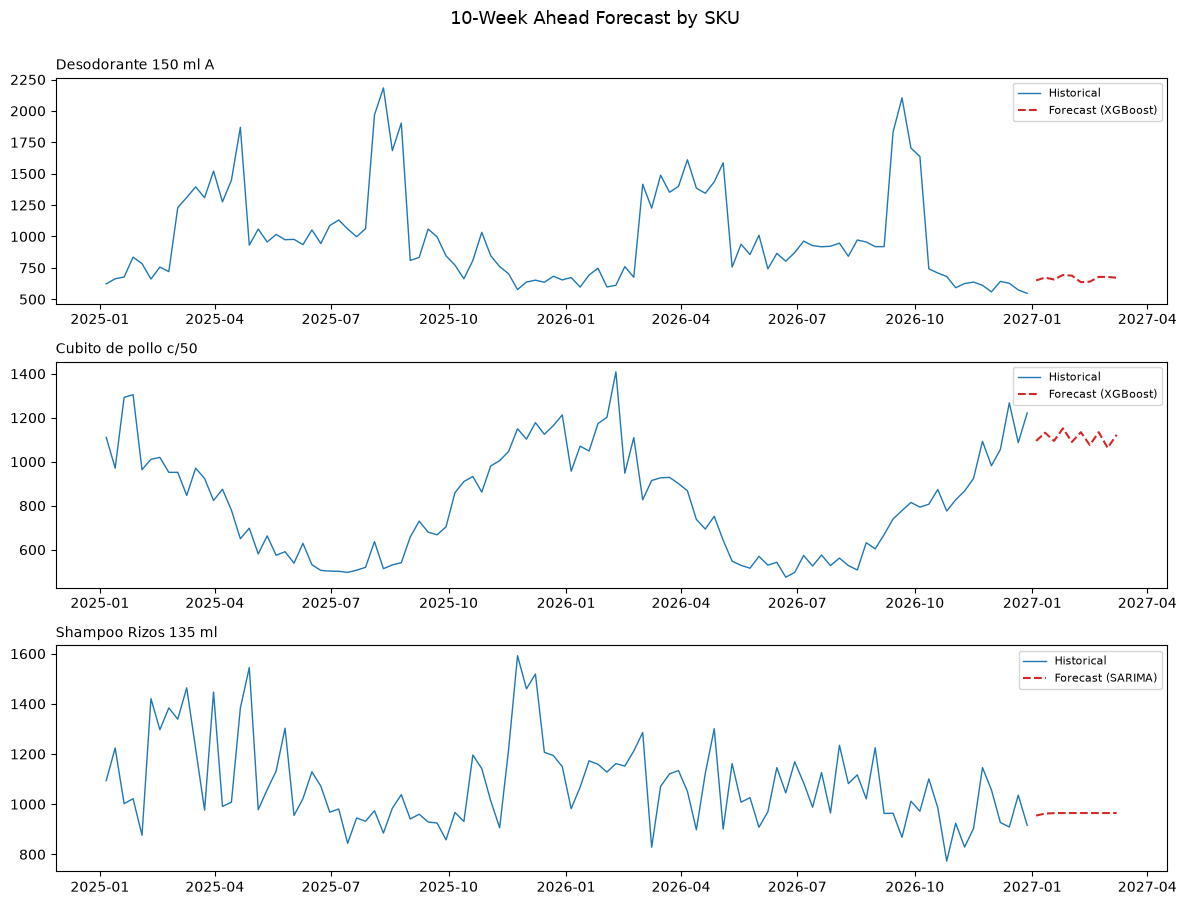

In [18]:
fig, axes = plt.subplots(len(selected_skus), 1, figsize=(12, 3 * len(selected_skus)), sharex=False)

for ax, sku in zip(axes, selected_skus):
    hist = forecast_data[forecast_data["product_name"] == sku]
    ax.plot(hist["week"], hist["sell_in_quantity"], label="Historical", linewidth=1)
    fc = future_forecasts[sku]
    ax.plot(fc["week"], fc["forecast"], label=f"Forecast ({winner[sku]})", linewidth=1.5, linestyle="--", color="tab:red")
    ax.set_title(sku, fontsize=10, loc="left")
    ax.legend(fontsize=8)

fig.suptitle(f"{FORECAST_WEEKS}-Week Ahead Forecast by SKU", fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig("../outputs/forecast_by_sku.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Challenge B: Price Elasticity

**SKU selection:** the case requires a single SKU with sufficient historical
price/discount variation. Effective price CV (`sell_in_amount / sell_in_quantity`,
excluding gifts and cancelled tickets) was computed across all 6 SKUs to make
this decision on data rather than intuition:

| SKU | Mean price | Std | CV (%) | Transactions |
|---|---|---|---|---|
| **Desodorante 150 ml A** | **52.67** | **5.32** | **10.10** | **64,325** |
| Antitranspirante 150 ml C | 55.98 | 5.58 | 9.98 | 35,113 |
| Cubito de pollo c/50 | 197.76 | 14.10 | 7.13 | 52,508 |
| Shampoo Rizos 135 ml | 19.42 | 1.17 | 6.00 | 69,840 |
| Shampoo 135 ml Azul | 19.05 | 0.93 | 4.89 | 44,608 |
| Shampoo 180ml Verde | 16.16 | 0.77 | 4.79 | 16,139 |

**Selected: Desodorante 150 ml A.**

- Highest price CV (10.10%) of all 6 SKUs — the case's explicit requirement.
- Second-highest transaction volume (64,325). Antitranspirante has a nearly
  identical CV (9.98%) but roughly half the volume (35,113), so Desodorante
  dominates on both criteria simultaneously — no trade-off needed.
- Already shown in Challenge A to have clear, well-documented promotional
  demand impact ("Combo Verano" spikes), which is favorable for elasticity
  estimation: price variation that actually moves demand, not just noisy
  variation with no apparent causal relationship.
- Shampoo Azul/Verde were already flagged as weak candidates in the EDA
  (Section 1) due to low price variation — now confirmed quantitatively
  (CV 4.79-4.89%, roughly half of Desodorante's).

In [19]:
pricing = df[~df["is_gift"] & ~df["is_cancelled"]].copy()
pricing["effective_price"] = pricing["sell_in_amount"] / pricing["sell_in_quantity"]

price_summary = (
    pricing.groupby("product_name")["effective_price"]
    .agg(["mean", "std", "count"])
    .assign(cv_pct=lambda x: (x["std"] / x["mean"] * 100).round(2))
    .sort_values("cv_pct", ascending=False)
)

price_summary


,mean,std,count,cv_pct
product_name,,,,
Desodorante 150 ml A,52.673595,5.320538,64325,10.10
Antitranspirante 150 ml C,55.982323,5.584438,35113,9.98
Cubito de pollo c/50,197.759772,14.098467,52508,7.13
Shampoo Rizos 135 ml,19.418771,1.165865,69840,6.00
Shampoo 135 ml Azul,19.054297,0.930910,44608,4.89
Shampoo 180ml Verde,16.163707,0.774626,16139,4.79


### 4.1 Elasticity Model: Approach

**Model:** log-log regression, controlling for calendar month:

log(quantity) = β₀ + β₁ · log(price) + β₂ · month_dummies

**Why log-log:** in a log-log specification, β₁ is directly interpretable as
price elasticity — the % change in demand for a 1% change in price. This is
exactly the definition of price sensitivity the case asks for, and it's
directly comparable to standard elasticity benchmarks a commercial team
would recognize.

**Why control for `month`:** Challenge A already showed Desodorante has
strong, predictable seasonality (Feb-Mar / Aug-Sep spikes tied to "Combo
Verano"). Price also drops during those same windows, since that's when
promotions run. Without a seasonality control, the model cannot separate
two different stories: "demand rose because price fell" (the real elasticity
effect) vs. "demand rose because it's high season, and price coincidentally
fell too due to the seasonal promo." Omitting `month` would attribute all of
that seasonal lift to price, inflating the elasticity estimate — making the
business look more price-sensitive than it actually is. Including `month`
lets the model separate the baseline seasonal effect from the marginal
effect of price, isolating the coefficient we actually want.

**Why NOT also control for `has_promo`:** `has_promo` and `price` are not
independent signals — when a promo is active, price drops; the lower price
*is* the promo, mechanically. Including both would introduce collinearity:
the model can't tell which of the two is driving the change in demand,
making the price coefficient unstable. It's also unnecessary for this
model's purpose — the elasticity simulator (Section 4.2) only needs "at this
price, what demand do we expect," regardless of whether that price came from
a formal promotion or an organic discount. Letting `price` absorb both is
the correct choice here, not a simplification that loses information.


In [20]:
sku_b = "Desodorante 150 ml A"

priced = df[
    (df["product_name"] == sku_b) &
    (~df["is_cancelled"]) &
    (~df["is_gift"])
].copy()

priced["week"] = priced["date"].dt.to_period("W").dt.start_time

weekly_price_qty = (
    priced.groupby("week")
    .agg(
        quantity=("sell_in_quantity", "sum"),
        amount=("sell_in_amount", "sum"),
        cost_total=("product_cost", "sum"),
    )
    .reset_index()
)

weekly_price_qty["price"] = weekly_price_qty["amount"] / weekly_price_qty["quantity"]
weekly_price_qty["unit_cost"] = weekly_price_qty["cost_total"] / weekly_price_qty["quantity"]
weekly_price_qty["month"] = weekly_price_qty["week"].dt.month

print(weekly_price_qty.shape)
weekly_price_qty[["week", "price", "quantity", "unit_cost"]].head()

(104, 7)


,week,price,quantity,unit_cost
0,2025-01-06,55.019597,623,45.081976
1,2025-01-13,55.004094,663,45.081977
2,2025-01-20,55.024552,677,45.081977
3,2025-01-27,55.007404,835,45.081977
4,2025-02-03,55.000815,776,45.081977


**Decision:** both gift transactions (`is_gift`) and cancelled tickets
(`is_cancelled`) are excluded from this dataset — gifts have `price = 0`,
which is not a real market response to price, and would bias the elasticity
estimate toward "infinite" sensitivity if included. Weekly effective price is
computed as **total revenue / total quantity** for the week (not an average
of per-transaction prices), which correctly weights each unit sold rather
than each transaction, avoiding distortion from transactions of very
different sizes.

### 4.2 Elasticity Estimate

Fitting the log-log model defined above and interpreting the resulting price elasticity coefficient.


In [21]:
import statsmodels.formula.api as smf

weekly_price_qty["log_qty"] = np.log(weekly_price_qty["quantity"])
weekly_price_qty["log_price"] = np.log(weekly_price_qty["price"])

model_elasticity = smf.ols("log_qty ~ log_price + C(month)", data=weekly_price_qty).fit()
print(model_elasticity.summary())

elasticity = model_elasticity.params["log_price"]
print(f"\nEstimated price elasticity: {elasticity:.3f}")

                            OLS Regression Results                            
Dep. Variable:                log_qty   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.923
Method:                 Least Squares   F-statistic:                     104.4
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           9.92e-48
Time:                        13:49:27   Log-Likelihood:                 102.99
No. Observations:                 104   AIC:                            -180.0
Df Residuals:                      91   BIC:                            -145.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         18.6182      0.636     29.

**Interpretation:** estimated price elasticity of **-2.998** (p < 0.001,
t = -19.05) — demand is elastic (|elasticity| > 1), meaning a 1% price
increase is associated with a ~3% drop in weekly volume. Month fixed effects
confirm the seasonality already observed in Challenge A: May-September carry
large, highly significant positive coefficients relative to January.

**Caveat:** an elasticity this high is larger than typically seen for a
recurring personal-care product (often -1 to -2). A likely explanation:
this measures **sell-in to distributor**, not consumer-level sales. When
price drops during a promotion, distributors commonly buy ahead of need
(forward buying) to capture the discount, inflating that week's volume
beyond what reflects true end-consumer demand. This is a real limitation
of estimating elasticity from sell-in data, not a modeling error, and
should be flagged when presenting this number to the commercial team —
the simulator below should be read as "distributor order response to
price," not strictly "consumer demand response."

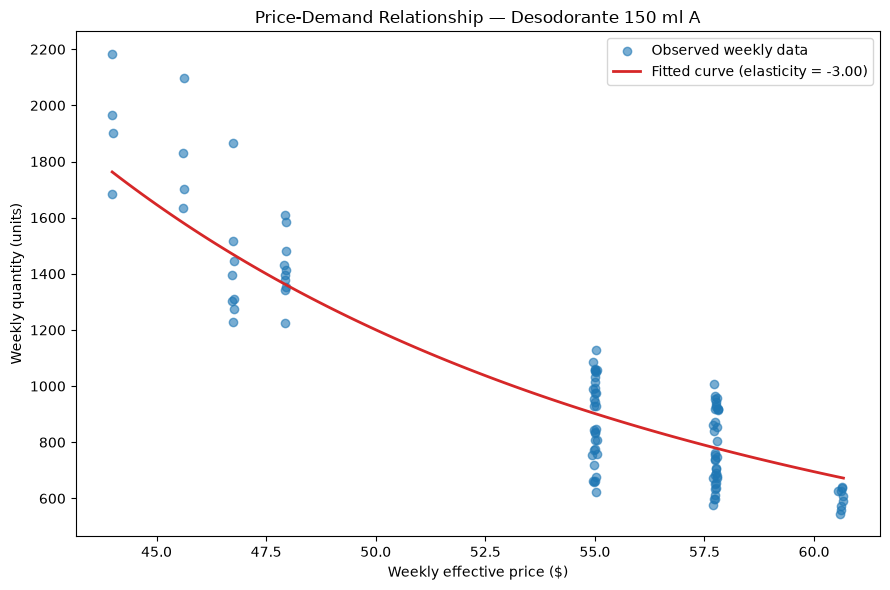

In [22]:
# Curva ajustada: precio vs cantidad esperada, manteniendo el mes en su valor promedio del periodo
price_range_plot = np.linspace(weekly_price_qty["price"].min(), weekly_price_qty["price"].max(), 100)

# Efecto promedio de mes: usamos el promedio de los coeficientes de mes como ajuste constante
month_effect_avg = model_elasticity.params[[c for c in model_elasticity.params.index if "C(month)" in c]].mean()

log_qty_fit = model_elasticity.params["Intercept"] + month_effect_avg + model_elasticity.params["log_price"] * np.log(price_range_plot)
qty_fit = np.exp(log_qty_fit)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(weekly_price_qty["price"], weekly_price_qty["quantity"], alpha=0.6, label="Observed weekly data", color="tab:blue")
ax.plot(price_range_plot, qty_fit, color="tab:red", linewidth=2, label=f"Fitted curve (elasticity = {elasticity:.2f})")
ax.set_xlabel("Weekly effective price ($)")
ax.set_ylabel("Weekly quantity (units)")
ax.set_title(f"Price-Demand Relationship — {sku_b}")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/price_elasticity_desodorante.png", dpi=150, bbox_inches="tight")
plt.show()

The fitted curve confirms the elasticity visually: as price rises across
its observed range, expected quantity falls sharply, consistent with the
estimated coefficient of ~-3.0. The scatter of observed points around the
curve reflects the month-to-month seasonal variation not captured by price
alone — explaining why the curve is a smooth average-month projection rather
than a perfect fit to every point.

In [23]:
price_min = weekly_price_qty["price"].min()
price_max = weekly_price_qty["price"].max()
print(f"Observed price range: {price_min:.2f} – {price_max:.2f}")

Observed price range: 43.99 – 60.67


### 4.3 Price Simulator

For any price within the observed range, estimates expected demand, revenue, and margin ($ and %), using the fitted elasticity model and current unit cost.


In [24]:
def price_simulator(price, model, unit_cost, product_margin, month=6):
    """
    Simulates expected demand, revenue, and margin at a given price.
    price: proposed unit price (must be within observed range)
    model: fitted OLS elasticity model
    unit_cost: unit cost to use for margin calc (e.g. latest observed unit_cost)
    product_margin: fixed markup fraction for this SKU
    month: reference month for seasonality (default: mid-year, average season)
    """
    if not (price_min <= price <= price_max):
        raise ValueError(f"Price {price} is outside the observed range [{price_min:.2f}, {price_max:.2f}] — not extrapolating.")

    log_price = np.log(price)
    month_col = f"C(month)[T.{month}]"
    month_effect = model.params[month_col] if month_col in model.params.index else 0.0

    log_qty_pred = model.params["Intercept"] + month_effect + model.params["log_price"] * log_price
    expected_qty = np.exp(log_qty_pred)

    revenue = price * expected_qty
    total_cost = unit_cost * expected_qty
    margin_dollars = revenue - total_cost
    margin_pct = margin_dollars / revenue * 100

    return {
        "price": price,
        "expected_qty": round(expected_qty, 1),
        "revenue": round(revenue, 2),
        "margin_dollars": round(margin_dollars, 2),
        "margin_pct": round(margin_pct, 2),
    }

# test at current average price
latest_unit_cost = weekly_price_qty["unit_cost"].iloc[-1]
print(price_simulator(price=52.0, model=model_elasticity, unit_cost=latest_unit_cost, product_margin=None))

{'price': 52.0, 'expected_qty': np.float64(1171.0), 'revenue': np.float64(60890.33), 'margin_dollars': np.float64(2689.86), 'margin_pct': np.float64(4.42)}


In [25]:
# Verificar consistencia: comparar el unit_cost usado vs. el markup esperado del dataset
print("unit_cost usado (latest observed):", latest_unit_cost)

# El product_margin real de este SKU en el dataset (debería ser constante)
sku_margin_check = df[df["product_name"] == sku_b]["product_margin"].dropna().unique()
print("product_margin en el dataset para este SKU:", sku_margin_check)

# Precio "esperado" si el mercado respetara ese markup sobre el costo actual
if len(sku_margin_check) == 1:
    implied_price = latest_unit_cost * (1 + sku_margin_check[0])
    print(f"Precio implícito por markup ({sku_margin_check[0]:.0%} sobre costo): {implied_price:.2f}")
    print(f"Precio simulado usado: 52.00")
    print(f"Rango de precio observado: {price_min:.2f} - {price_max:.2f}")

# También revisa la evolución reciente del unit_cost semanal (¿hay un salto?)
print("\nÚltimas 8 semanas de unit_cost:")
print(weekly_price_qty[["week", "unit_cost", "price"]].tail(8))

unit_cost usado (latest observed): 49.70287527472527
product_margin en el dataset para este SKU: [0.22]
Precio implícito por markup (22% sobre costo): 60.64
Precio simulado usado: 52.00
Rango de precio observado: 43.99 - 60.67

Últimas 8 semanas de unit_cost:
          week  unit_cost      price
96  2026-11-09  49.702878  60.546222
97  2026-11-16  49.702877  60.641518
98  2026-11-23  49.702878  60.669791
99  2026-11-30  49.702876  60.604626
100 2026-12-07  49.702876  60.632082
101 2026-12-14  49.702877  60.621526
102 2026-12-21  49.702877  60.607227
103 2026-12-28  49.702875  60.598792


**Assumption — current cost basis:** `unit_cost` is not constant over time
(confirmed in Section 1 — it's a step function driven by periodic supplier
updates, ~45.08 in Jan 2025 rising to ~49.70 by late 2026, a ~10% increase).
The simulator below uses the **most recently observed unit_cost** for all
margin calculations, meaning results should be read as "expected margin
under today's cost structure." If unit cost rises again — as it has twice
in the observed history — actual margins at any simulated price would be
lower than projected here. This is a necessary simplification: the case
does not ask to forecast future cost, only to simulate price scenarios, so
holding cost fixed at its current level is the most defensible baseline.

In [26]:
price_grid = np.linspace(price_min, price_max, 50)

sim_results = [
    price_simulator(price=p, model=model_elasticity, unit_cost=latest_unit_cost, product_margin=0.22, month=6)
    for p in price_grid
]

sim_df = pd.DataFrame(sim_results)
sim_df.head(10)

,price,expected_qty,revenue,margin_dollars,margin_pct
0,43.988131,1933.9,85066.69,-11051.49,-12.99
1,44.328573,1889.7,83766.19,-10155.64,-12.12
2,44.669015,1846.8,82495.30,-9296.60,-11.27
3,45.009457,1805.2,81253.12,-8472.77,-10.43
4,45.349899,1764.9,80038.80,-7682.64,-9.60
5,45.690341,1725.8,78851.50,-6924.75,-8.78
6,46.030783,1687.8,77690.44,-6197.73,-7.98
7,46.371225,1650.9,76554.84,-5500.26,-7.18
8,46.711667,1615.1,75443.96,-4831.10,-6.40
9,47.052109,1580.3,74357.10,-4189.04,-5.63


**Key observation:** at the lower end of the observed price range (~$44-47),
simulated margin is **negative** (-13% to -6%). This is not a modeling error
— it's the direct consequence of the cost-basis assumption above: those
price levels were historically paired with a *lower* unit cost (~$45 in
early 2025), but the simulator evaluates them against **today's** unit cost
(~$49.70). At today's cost structure, reverting to those historical low
prices would mean selling below cost. This reinforces that the low end of
the observed price range is not a viable pricing zone under current
conditions, regardless of what elasticity alone would suggest.

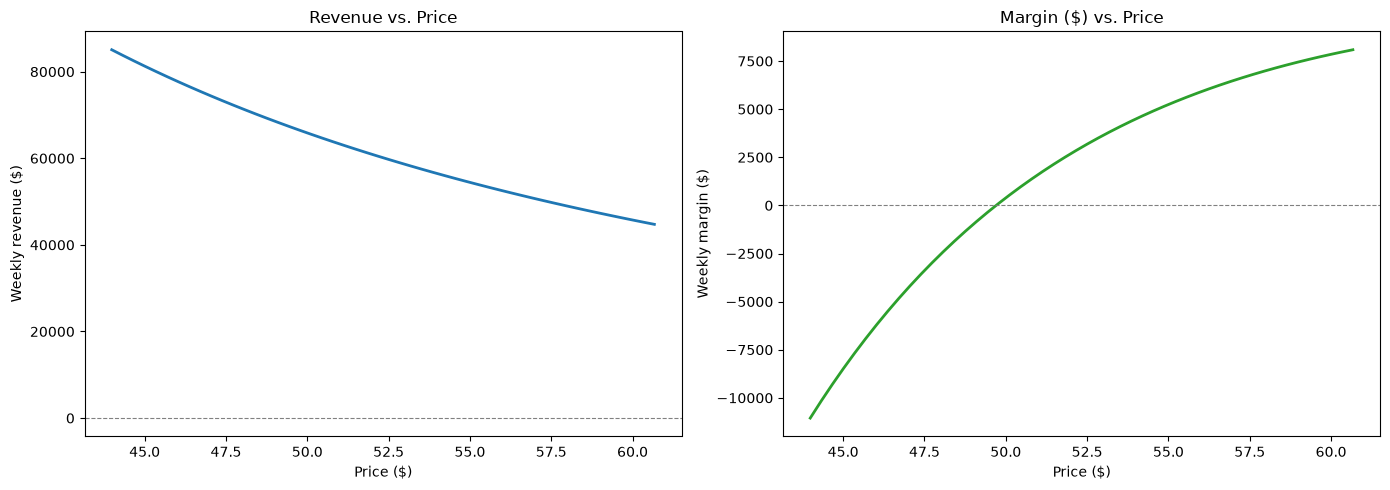

Price that maximizes REVENUE:
price                43.988131
expected_qty       1933.900000
revenue           85066.690000
margin_dollars   -11051.490000
margin_pct          -12.990000
Name: 0, dtype: float64

Price that maximizes MARGIN ($):
price                60.669791
expected_qty        737.500000
revenue           44742.960000
margin_dollars     8087.920000
margin_pct           18.080000
Name: 49, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sim_df["price"], sim_df["revenue"], color="tab:blue", linewidth=2)
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Weekly revenue ($)")
axes[0].set_title("Revenue vs. Price")
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")

axes[1].plot(sim_df["price"], sim_df["margin_dollars"], color="tab:green", linewidth=2, label="Margin ($)")
axes[1].set_xlabel("Price ($)")
axes[1].set_ylabel("Weekly margin ($)")
axes[1].set_title("Margin ($) vs. Price")
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("../outputs/price_simulator_revenue_margin.png", dpi=150, bbox_inches="tight")
plt.show()

# Identificar precio que maximiza ingreso y precio que maximiza margen $
best_revenue_row = sim_df.loc[sim_df["revenue"].idxmax()]
best_margin_row = sim_df.loc[sim_df["margin_dollars"].idxmax()]

print("Price that maximizes REVENUE:")
print(best_revenue_row)
print("\nPrice that maximizes MARGIN ($):")
print(best_margin_row)

### 4.4 Conclusion: Recommended Price Zone

**Recommendation:** price Desodorante 150 ml A in the **$55–$60** range,
rather than seeking a single "optimal" price.

- No interior optimum exists in the observed data: revenue is maximized at
  the lowest observed price and margin ($) at the highest — a pure trade-off
  throughout the range, with no point where both improve together.
- The $55-60 zone keeps margin solidly positive (~14-18%) while preserving
  meaningful sales volume, avoiding the ~62% volume collapse seen at the top
  of the range.
- This zone overlaps with prices the business has already charged
  historically, so customer acceptance at this level is evidenced by actual
  data, not extrapolated.

**Risks and assumptions limiting this estimate:**

1. **Sell-in, not consumer demand.** The elasticity (-2.998) is estimated
   from distributor sell-in, not end-consumer sales. Forward buying around
   promotions likely inflates the measured sensitivity — the true
   consumer-level elasticity is probably lower in magnitude.
2. **Cost held fixed at today's level.** The simulator uses the most
   recently observed `unit_cost` (~$49.70) for all price scenarios. Unit
   cost has risen ~10% over the observed history (step changes from supplier
   updates); if it rises again, actual margins at any price would be lower
   than projected.
3. **No extrapolation, but sparse coverage within range.** Observed prices
   cluster around ~6 discrete levels rather than varying continuously — the
   fitted curve interpolates between these clusters, so confidence is
   strongest near the observed levels and weaker in the gaps between them.
4. **Demand-side controls limited to month.** Other factors that might
   correlate with both price and demand (competitor actions, macro
   conditions, distribution changes) are not observed or controlled for,
   and could bias the elasticity estimate in either direction.
5. **Single-SKU estimate.** This elasticity applies to Desodorante 150 ml A
   specifically; it should not be assumed to generalize to other SKUs,
   even within the same category.

## 5. Challenge C: Promotional Uplift

**Approach:** the case requires selecting at least 2 past promotions and
estimating incremental sales for each, with methodology left to our
discretion. Before choosing which promotions to analyze, all 19 combos are
inventoried by SKU, date range, discount depth, and volume — to select
promotions that are cleanly measurable: enough baseline history before/after,
no overlap with a concurrent promotion on the same SKU, and enough
transaction volume to trust the estimate.

In [28]:
combos = df[df["id_combo"].notnull()].copy()

combo_summary = (
    combos.groupby(["id_combo", "combo", "product_name"])
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        n_transactions=("ticket_code", "count"),
        total_qty=("sell_in_quantity", "sum"),
        avg_discount=("discount", "mean"),
    )
    .reset_index()
    .sort_values("start_date")
)

combo_summary["duration_days"] = (combo_summary["end_date"] - combo_summary["start_date"]).dt.days

print(f"Total combos: {combo_summary['id_combo'].nunique()}")
combo_summary.head(20)

Total combos: 19


,id_combo,combo,product_name,start_date,end_date,n_transactions,total_qty,avg_discount,duration_days
0,20001.0,Combo Año Nuevo Caldos,Cubito de pollo c/50,2025-01-20,2025-02-16,2853,4573,0.141592,27
8,20201.0,Combo Regreso a Clases Cabello,Shampoo Rizos 135 ml,2025-02-10,2025-03-23,5039,8126,0.121486,41
13,20401.0,Combo Verano Desodorante,Desodorante 150 ml A,2025-03-03,2025-04-27,7116,11359,0.151425,55
4,20101.0,Combo Verano Antitranspirante,Antitranspirante 150 ml C,2025-03-03,2025-04-27,3725,5994,0.152336,55
11,20301.0,Combo Azul Primavera,Shampoo 135 ml Azul,2025-04-21,2025-05-25,2462,3979,0.131283,34
1,20002.0,Combo Temporada Fría,Cubito de pollo c/50,2025-05-26,2025-07-06,2073,3300,0.100438,41
17,20501.0,Combo Verde Chico,Shampoo 180ml Verde,2025-06-30,2025-07-27,730,1208,0.140945,27
14,20402.0,Combo Quincena Desodorante,Desodorante 150 ml A,2025-08-04,2025-08-31,4904,7738,0.200487,27
5,20102.0,Combo Quincena,Antitranspirante 150 ml C,2025-08-04,2025-08-31,2771,4396,0.201557,27
9,20202.0,Combo Cabello Sano,Shampoo Rizos 135 ml,2025-11-17,2025-12-21,4424,6996,0.151431,34


### 5.1 Methodology

**Selected promotions:** Combo Verano Desodorante 2 (Mar–May 2026, 17.1%
avg discount) and Combo Cierre Trimestre Desodorante (Sep–Oct 2026, 21.1%
avg discount, the deepest discount of all 19 combos). Both are on the same
SKU used in Challenges A and B, allowing uplift findings to connect directly
with the elasticity and forecasting results already established.

**Method:** before/after baseline. For each promotion, a baseline weekly
demand is computed as the average of the weeks immediately preceding the
promotion (non-promotional, no overlap with another Desodorante combo).
Incremental units are:

uplift_units = actual_units_during_promo − (baseline_weekly_avg × promo_duration_weeks)

This was chosen over a year-over-year (seasonal-naive) baseline because the
same calendar window in the prior year also carried a promotion for this SKU
— comparing promo-to-promo would not isolate an incremental effect, only
compare two already-inflated periods against each other.

**Limitation:** this method assumes baseline demand would have stayed flat
for the duration of the promotion window, absent the promotion. It does not
account for trend or seasonality *within* that window — a bigger risk for
the 69-day Verano 2 promotion than the 27-day Cierre Trimestre promotion.


### 5.2 Step 1: Incremental Units

The first question is the most basic one: how many *extra* units did each
promotion sell, beyond what would have sold anyway? `compute_uplift`
calculates a baseline from the 6 weeks immediately before each promotion
(non-promotional demand), scales it to the promotion's duration, and
compares it to actual units sold during the promotion window. The
difference is the incremental volume.

This alone answers "did the promotion move volume" — but it says nothing
about whether that volume was profitable, which is the next question.

In [29]:
def compute_uplift(sku, promo_start, promo_end, baseline_weeks=6):
    sku_weekly = (
        demand[demand["product_name"] == sku]
        .assign(week=lambda d: d["date"].dt.to_period("W").dt.start_time)
        .groupby("week")["sell_in_quantity"].sum()
        .reset_index()
        .sort_values("week")
    )

    promo_start, promo_end = pd.Timestamp(promo_start), pd.Timestamp(promo_end)
    promo_mask = (sku_weekly["week"] >= promo_start) & (sku_weekly["week"] <= promo_end)
    actual_units = sku_weekly.loc[promo_mask, "sell_in_quantity"].sum()
    promo_weeks = promo_mask.sum()

    baseline_mask = (sku_weekly["week"] < promo_start) & (sku_weekly["week"] >= promo_start - pd.Timedelta(weeks=baseline_weeks))
    baseline_avg = sku_weekly.loc[baseline_mask, "sell_in_quantity"].mean()

    expected_units = baseline_avg * promo_weeks
    uplift_units = actual_units - expected_units
    uplift_pct = (uplift_units / expected_units) * 100

    return {
        "promo_weeks": promo_weeks,
        "baseline_weekly_avg": round(baseline_avg, 1),
        "expected_units": round(expected_units, 1),
        "actual_units": actual_units,
        "uplift_units": round(uplift_units, 1),
        "uplift_pct": round(uplift_pct, 1),
    }

verano2 = compute_uplift("Desodorante 150 ml A", "2026-03-02", "2026-05-10")
cierre_trimestre = compute_uplift("Desodorante 150 ml A", "2026-09-14", "2026-10-11")

print("Combo Verano Desodorante 2:", verano2)
print("\nCombo Cierre Trimestre Desodorante:", cierre_trimestre)

Combo Verano Desodorante 2: {'promo_weeks': np.int64(10), 'baseline_weekly_avg': np.float64(680.7), 'expected_units': np.float64(6806.7), 'actual_units': np.int64(14243), 'uplift_units': np.float64(7436.3), 'uplift_pct': np.float64(109.3)}

Combo Cierre Trimestre Desodorante: {'promo_weeks': np.int64(4), 'baseline_weekly_avg': np.float64(925.8), 'expected_units': np.float64(3703.3), 'actual_units': np.int64(7277), 'uplift_units': np.float64(3573.7), 'uplift_pct': np.float64(96.5)}


**Result:** both promotions show large positive uplift (+109% for Verano 2,
+96.5% for Cierre Trimestre) — both clearly moved volume. But uplift in
units doesn't tell us whether the business made or lost money: a deep
discount can generate large volume while destroying margin. Since we
already have cost and margin data available (from Challenge B), the next
step translates this from "units" into "$ margin" — the metric that
actually determines whether a promotion is worth replicating.

`compute_margin_impact` compares actual revenue/cost/margin during the
promotion window against a counterfactual: what margin the baseline
(non-promo) weekly demand would have earned at non-promo pricing and cost,
scaled to the same time window.

In [30]:
def compute_margin_impact(sku, promo_start, promo_end, promo_weeks_baseline_avg, promo_weeks):
    promo_txns = df[
        (df["product_name"] == sku) &
        (df["date"] >= promo_start) & (df["date"] <= promo_end) &
        (~df["is_cancelled"])
    ]

    actual_revenue = promo_txns["sell_in_amount"].sum()
    actual_cost = promo_txns["product_cost"].sum()
    actual_margin = actual_revenue - actual_cost

    # Counterfactual: what baseline (non-promo) weekly demand would have earned at non-promo pricing
    non_promo_recent = df[
        (df["product_name"] == sku) &
        (df["date"] < promo_start) &
        (df["date"] >= promo_start - pd.Timedelta(weeks=6)) &
        (~df["is_cancelled"]) & (~df["is_gift"])
    ]
    baseline_price = non_promo_recent["sell_in_amount"].sum() / non_promo_recent["sell_in_quantity"].sum()
    baseline_unit_cost = non_promo_recent["product_cost"].sum() / non_promo_recent["sell_in_quantity"].sum()

    expected_units = promo_weeks_baseline_avg * promo_weeks
    expected_revenue = expected_units * baseline_price
    expected_cost = expected_units * baseline_unit_cost
    expected_margin = expected_revenue - expected_cost

    incremental_margin = actual_margin - expected_margin

    return {
        "actual_revenue": round(actual_revenue, 2),
        "actual_margin": round(actual_margin, 2),
        "expected_margin_no_promo": round(expected_margin, 2),
        "incremental_margin": round(incremental_margin, 2),
    }

margin_verano2 = compute_margin_impact("Desodorante 150 ml A", pd.Timestamp("2026-03-02"), pd.Timestamp("2026-05-10"), 680.7, 10)
margin_cierre = compute_margin_impact("Desodorante 150 ml A", pd.Timestamp("2026-09-14"), pd.Timestamp("2026-10-11"), 925.8, 4)

print("Verano 2 margin impact:", margin_verano2)
print("\nCierre Trimestre margin impact:", margin_cierre)

Verano 2 margin impact: {'actual_revenue': np.float64(681252.39), 'actual_margin': np.float64(7044.65), 'expected_margin_no_promo': np.float64(70812.32), 'incremental_margin': np.float64(-63767.67)}

Cierre Trimestre margin impact: {'actual_revenue': np.float64(331465.37), 'actual_margin': np.float64(-12999.26), 'expected_margin_no_promo': np.float64(38617.58), 'incremental_margin': np.float64(-51616.83)}


**Result:** counter to what the unit uplift suggested, both promotions show
**negative incremental margin** (-$63,768 for Verano 2, -$51,617 for Cierre
Trimestre) — despite both generating large positive unit uplift. This needs
to be unpacked before drawing any conclusion, because "incremental margin"
as calculated above mixes two very different effects:

1. **Margin given up on units that would have sold anyway** (the baseline
   volume) — these units sold at the discounted promo price instead of the
   regular price, losing margin that was already secured.
2. **Margin actually earned on the truly incremental units** (the uplift) —
   this is the number that matters for deciding whether the promotion
   itself was a good idea, since the baseline units were never really "at
   risk" of not selling.

Without separating these two effects, a promotion could look like a total
failure even if the incremental units themselves were profitable — the
loss could be coming entirely from discounting volume that didn't need a
discount to sell. `decompose_margin` splits the total margin impact into
these two components.

In [31]:
def decompose_margin(actual_revenue, actual_margin, actual_units, expected_margin, expected_units, uplift_units):
    promo_margin_per_unit = actual_margin / actual_units
    baseline_margin_per_unit = expected_margin / expected_units

    margin_lost_on_baseline_units = expected_units * (baseline_margin_per_unit - promo_margin_per_unit)
    margin_from_incremental_units = uplift_units * promo_margin_per_unit

    return {
        "baseline_margin_per_unit": round(baseline_margin_per_unit, 2),
        "promo_margin_per_unit": round(promo_margin_per_unit, 2),
        "margin_lost_on_baseline_units": round(margin_lost_on_baseline_units, 2),
        "margin_from_incremental_units": round(margin_from_incremental_units, 2),
    }

decomp_verano2 = decompose_margin(681252.39, 7044.65, 14243, 70812.32, 6806.7, 7436.3)
decomp_cierre = decompose_margin(331465.37, -12999.26, 7277, 38617.58, 3703.3, 3573.7)

print("Verano 2 decomposition:", decomp_verano2)
print("\nCierre Trimestre decomposition:", decomp_cierre)

Verano 2 decomposition: {'baseline_margin_per_unit': 10.4, 'promo_margin_per_unit': 0.49, 'margin_lost_on_baseline_units': 67445.7, 'margin_from_incremental_units': 3678.03}

Cierre Trimestre decomposition: {'baseline_margin_per_unit': 10.43, 'promo_margin_per_unit': -1.79, 'margin_lost_on_baseline_units': 45232.97, 'margin_from_incremental_units': -6383.87}


### 5.3 Conclusion: Which Promotion to Replicate

**Recommend replicating (with adjustment): Combo Verano Desodorante 2.**
The incremental units it generated were genuinely profitable (+$3,678 in
margin on the uplift alone) — the promotional mechanic works and drives
real incremental demand. However, the discount (17.1%) was deep enough to
also erode margin on baseline volume that would have sold anyway
(-$67,446), making the promotion net-negative overall (-$63,768). The
recommendation is not to abandon this type of promotion, but to **reduce
the discount depth** in future runs — enough to still trigger meaningful
incremental demand (elasticity ≈ -3.0, from Challenge B, suggests real
sensitivity exists even at shallower discounts) while protecting margin on
the volume that doesn't need a discount to convert.

**Recommend NOT replicating: Combo Cierre Trimestre Desodorante.** Unlike
Verano 2, even the incremental units here were sold at a loss (-$1.79
margin/unit, -$6,384 total). This isn't a calibration problem — at this
discount depth (21.1%, the deepest of all 19 combos) and current unit cost,
there is no volume of incremental sales that makes this promotion
profitable. The discount should either be reduced substantially or this
promotion should be discontinued in its current form.

**Underlying driver:** both promotions were designed against list prices
that no longer leave the margin cushion they once did — unit cost has risen
~10% over the observed history (Challenge B, Section 6.5), but promotional
discount depths appear not to have been re-calibrated against that rising
cost. This is likely the single highest-leverage fix available to the
commercial team: review discount tiers against *current* cost before
running these promotions again, rather than reusing historical discount
percentages by default.